<a href="https://colab.research.google.com/github/Vronska-Anhelina/Product-Frameworks/blob/main/Accounts_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
data = pd.read_csv("/content/drive/MyDrive/bq-results-20260520-144950-1779288627070.csv")
data.head()

Mounted at /content/drive


,account_id,visit_cnt,last_visit_date,revenue
0,671969,4,2020-12-24,40
1,668655,3,2021-01-23,30
2,673773,5,2020-12-18,50
3,661850,1,2020-11-27,10
4,664958,1,2020-11-26,10


In [ ]:
import pandas as pd
import plotly.express as px
df["last_visit_date"] = pd.to_datetime(df["last_visit_date"])
date = df["last_visit_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("account_id").agg({
    "last_visit_date": lambda x: (date - x.max()).days,
    "visit_cnt": "sum",
    "revenue": "sum"
}).rename(columns={
    "last_visit_date": "Recency",
    "visit_cnt": "Frequency",
    "revenue": "Monetary"
})

rfm["R_Score"] = pd.cut(rfm["Recency"], bins=[-1, 30, 60, rfm["Recency"].max()], labels=[3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"], q=4, labels=False, duplicates="drop") + 1
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=False, duplicates="drop") + 1
def segment(row):
    rfm_score = row["F_Score"] + row["M_Score"]

    if row["R_Score"] > 1 and rfm_score > 5:
        return "Top"
    if row["R_Score"] == 1 and rfm_score < 4:
        return "Lost"
    else:
        return "Middle"


rfm["Segment"] = rfm.apply(segment, axis=1)
segment_counts = rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count of account"]
print(f"Account segments:\n{segment_counts}")

Account segments:
  Segment  Count of account
0  Middle              2974
1    Lost               804
2     Top               685


/tmp/ipykernel_587/2084997325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x="Segment",palette="viridis")


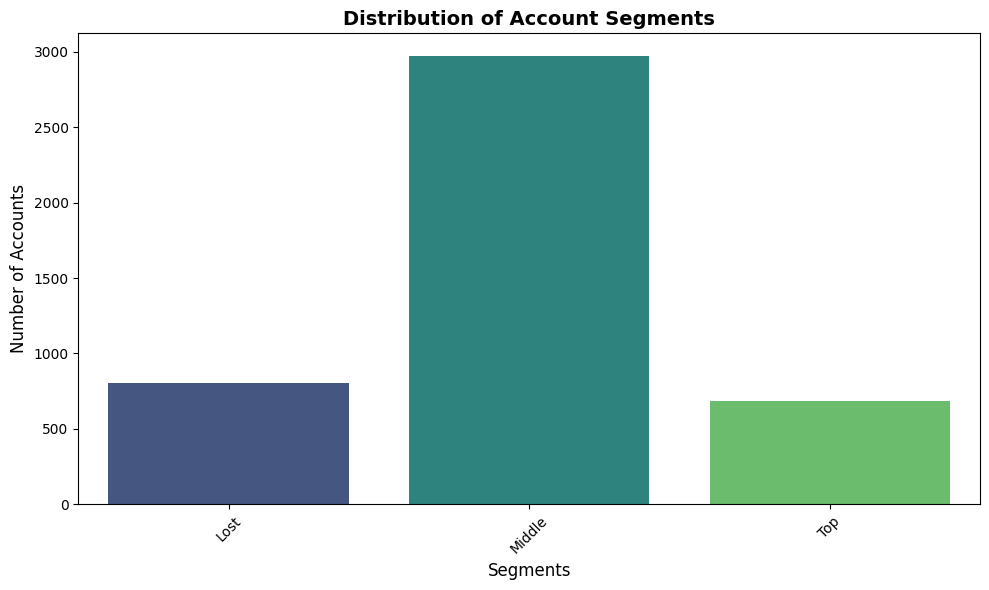

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x="Segment",palette="viridis")
plt.title("Distribution of Account Segments", fontsize=14, fontweight="bold")
plt.xlabel("Segments", fontsize=12)
plt.ylabel("Number of Accounts", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()